# 多头自注意力模块

下面在SingleHeadSelfAttention的基础上实现多头注意力

注意这里的

`Q = self.w_q(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)`

将原来的self.w_q(x)的结果 (batch_size, seq_len, d_model) 先用`view`将其变成形状为 (batch_size, seq_len, num_heads, d_k)

这一步主要是将原来的d_model切分为num_heads个部分分别计算注意力

然后为了后面的`matmul`能正常进行, 交换seq_len, num_heads维度, 变为 (batch_size, num_heads, seq_len, d_k)

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F

from sklearn.metrics import classification_report

class MultiHeadAttention(nn.Module):
    def __init__(self, vocab_size, output_dim, d_model, num_heads): # 加入num_heads参数设置头数量
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads # 按照num_heads切分d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, output_dim)
        self.attn_w = None
    
    def forward(self, x):
        """
        x: (batch, seq_len)
        """
        batch_size = x.size(0)
        x = self.embedding(x)  # (batch, seq_len, d_model)
        Q = self.w_q(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.w_k(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.w_v(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        # score: (batch, query, key) --- 序列内各位置之间的注意力, query为token位置, key为看的那个位置
        score = Q @ K.transpose(-2, -1) / self.d_k ** 0.5
        attn_w = torch.softmax(score, dim=-1)
        self.attn_w = attn_w.detach()
        output = attn_w @ V # (batch, num_heads, seq_len, d_k)
        output = output.transpose(1, 2).reshape(batch_size, -1, self.d_model) # 将多头的输出拼接回原来的维度
        return self.out(output) # (batch, seq_len, output_dim)


In [2]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Microsoft YaHei"
plt.rcParams["axes.unicode_minus"] = False

def plot_attention(attn_w, tokens, title="Head", cmap="Blues"):
    # attn_w: (num_heads, T, T)
    
    num_heads = attn_w.shape[0]
    seq_len = attn_w.shape[1]
    attn_w = attn_w.detach().cpu().float()

    cell = seq_len * 0.5 + 0.5
    fig, axes = plt.subplots(2, 2, figsize=(cell * 2, cell * 2), constrained_layout=True)

    for n in range(4):
        ax = axes[n // 2][n % 2]
        if n < num_heads:
            im = ax.imshow(attn_w[n], cmap=cmap, vmin=0, vmax=1)
            ax.set_xticks(range(seq_len))
            ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=7)
            ax.set_yticks(range(seq_len))
            ax.set_yticklabels(tokens, fontsize=7)
            ax.set_title(f"{title} Head-{n}", fontsize=9)
            for i in range(seq_len):
                for j in range(seq_len):
                    val = attn_w[n, i, j].item()
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                            fontsize=6, color="white" if val > 0.6 else "black")
        else:
            ax.axis('off')

    plt.colorbar(im, ax=axes, fraction=0.02, pad=0.04)
    plt.show()

 # 实验1 同时找最大值和最小值的下标

 

In [6]:
def get_batch_max_min(batch, sql_len, low, high):
    train_x = torch.randint(low, high, (batch, sql_len), dtype=torch.long)  # (batch_size, n)
    max_y = torch.argmax(train_x, dim=-1)  # (batch_size,)
    min_y = torch.argmin(train_x, dim=-1)  # (batch_size,)
    return train_x, torch.stack([max_y, min_y], dim=-1)  # (batch_size, 2)

epochs = 100

model = MultiHeadAttention(vocab_size=100, output_dim=2, d_model=32, num_heads=4)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

model.train()
for i in range(epochs):
    train_x, train_y = get_batch_max_min(1024, 10, 0, 100)
    optimizer.zero_grad()
    pred = model(train_x)  # (batch, seq_len, 2)

    pred_max = pred[:, :, 0]  # (batch, seq_len)
    pred_min = pred[:, :, 1]  # (batch, seq_len)
    loss_max = criterion(pred_max, train_y[:, 0])
    loss_min = criterion(pred_min, train_y[:, 1])
    loss = loss_max + loss_min

    loss.backward()
    optimizer.step()
    if (i+1) % 10 == 0:
        print(
            f"Epoch {i+1}, Loss: {loss.item():.4f}, "
            f"MaxLoss: {loss_max.item():.4f}, MinLoss: {loss_min.item():.4f}"
        )


Epoch 10, Loss: 3.3083, MaxLoss: 1.4924, MinLoss: 1.8160
Epoch 20, Loss: 1.5898, MaxLoss: 0.7034, MinLoss: 0.8864
Epoch 30, Loss: 0.7940, MaxLoss: 0.3579, MinLoss: 0.4360
Epoch 40, Loss: 0.4227, MaxLoss: 0.1874, MinLoss: 0.2353
Epoch 50, Loss: 0.3207, MaxLoss: 0.1424, MinLoss: 0.1784
Epoch 60, Loss: 0.2224, MaxLoss: 0.1022, MinLoss: 0.1202
Epoch 70, Loss: 0.2128, MaxLoss: 0.1035, MinLoss: 0.1093
Epoch 80, Loss: 0.1716, MaxLoss: 0.0825, MinLoss: 0.0890
Epoch 90, Loss: 0.1583, MaxLoss: 0.0787, MinLoss: 0.0796
Epoch 100, Loss: 0.1369, MaxLoss: 0.0719, MinLoss: 0.0650


input : [98, 98, 76, 49, 60, 13, 35, 83, 36, 26]
pred  : [max=0, min=5]
target: [max=0, min=5]
------------------------------
input : [79, 13, 62, 67, 45, 47, 37, 79, 50, 26]
pred  : [max=0, min=1]
target: [max=0, min=1]
------------------------------
input : [26, 30, 23, 59, 93, 93, 23, 68, 12, 22]
pred  : [max=4, min=8]
target: [max=4, min=8]
------------------------------
input : [82, 2, 14, 48, 6, 97, 85, 63, 2, 86]
pred  : [max=5, min=1]
target: [max=5, min=1]
------------------------------


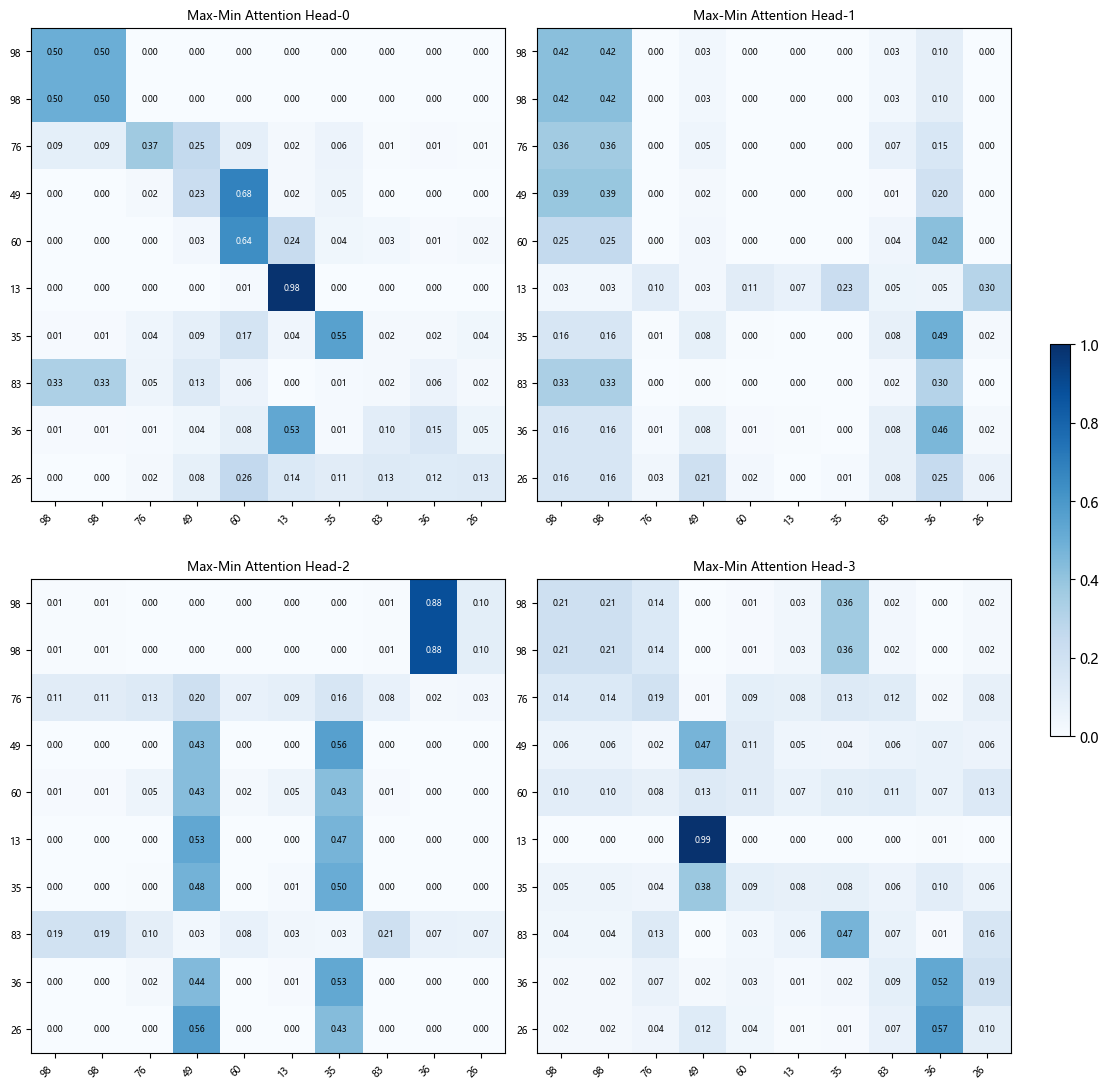

In [9]:
test_x, test_y = get_batch_max_min(4, 10, 1, 100)
sample_tokens = [str(v) for v in test_x[0].tolist()]

model.eval()
with torch.no_grad():
    pred = model(test_x)
    pred_max = pred[:, :, 0].argmax(dim=-1)
    pred_min = pred[:, :, 1].argmax(dim=-1)

    for i in range(test_x.size(0)):
        print(f"input : {test_x[i].tolist()}")
        print(f"pred  : [max={pred_max[i].item()}, min={pred_min[i].item()}]")
        print(f"target: [max={test_y[i,0].item()}, min={test_y[i,1].item()}]")
        print("-" * 30)

    plot_attention(model.attn_w[0], tokens=sample_tokens, title="Max-Min Attention")



 # 实验2 序列排序



In [ ]:
def get_sort_batch(batch_size, seq_len, vocab_size):
    """
    排序任务数据集
    输入: 乱序的整数序列      e.g. [3, 1, 4, 1, 5, 2]
    标签: 升序排列后的序列    e.g. [1, 1, 2, 3, 4, 5]
    """
    x = torch.randint(0, vocab_size, (batch_size, seq_len), dtype=torch.long)
    y = x.sort(dim=-1).values  # (batch_size, seq_len), long
    return x, y

# 验证一下
x, y = get_sort_batch(4, 6, 10)
for i in range(4):
    print(f"input: {x[i].tolist()}  →  sorted: {y[i].tolist()}")


epochs = 1000

model = MultiHeadAttention(vocab_size=10, output_dim=10, d_model=64, num_heads=4)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
criterion = nn.CrossEntropyLoss()

model.train()
for i in range(epochs):
    train_x, train_y = get_sort_batch(1024, 10, 10)
    optimizer.zero_grad()
    pred = model(train_x)                      # (batch, seq_len, vocab_size)
    loss = criterion(pred.transpose(1, 2), train_y)
    loss.backward()
    optimizer.step()
    if (i+1) % 100 == 0:
        print(f"Epoch {i+1}, Loss: {loss.item():.4f}")




In [ ]:

test_x, test_y = get_sort_batch(4, 6, 10)
model.eval()
with torch.no_grad():
    pred = model(test_x)                   # 触发 forward，缓存 attn_w
    pred_tokens = pred[0].argmax(dim=-1)   # (seq_len,)

print("input :", test_x[0].tolist())
print("pred  :", pred_tokens.tolist())
print("target:", test_x[0].sort().values.tolist())

# model.attn_w: (batch, num_heads, seq_len, seq_len)
sample_tokens = [str(v) for v in test_x[0].tolist()]
plot_attention(
    model.attn_w[0],           # (num_heads, T, T)
    tokens=sample_tokens,
    title="Multi-Head Attention"
)

